# Previsão de Produtividade Municipal da Soja no RS — Análise Exploratória

**Integrantes:** Isabelle Franco (RA 10425395) · Gustavo Rodrigues (RA 10403091) · Pedro Henrique (RA 10388298) · Lorenzo Tadeo (RA 10420067)
**Orientador:** Prof. Dr. Ivan Carlos Alcântara de Oliveira

**Síntese do conteúdo deste arquivo:** carrega os dados brutos do IBGE/SIDRA (Tabela 1612), do índice ONI (NOAA) e do INMET (45 estações automáticas do RS), calcula a estação meteorológica mais próxima de cada município, agrega clima e ONI por janela de safra (outubro do ano anterior a março do ano da safra), monta o painel município×safra (salvo em `dataset/processed/painel_municipio_safra.csv`) e realiza a análise exploratória inicial: cobertura dos dados, distribuição do rendimento, série temporal rendimento×ONI e matriz de correlação.

| Data       | Autor           | Descrição                                                                 |
|------------|-----------------|-----------------------------------------------------------------------------|
| 2026-09-24 | [nome do autor] | Criação do notebook — carga dos dados reais, integração município–safra e primeira análise exploratória |


## 1. Imports e configuração

Este notebook assume que é executado a partir da pasta `notebooks/` do repositório
(estrutura padrão do Jupyter), lendo os dados brutos em `../dataset/raw/`.

In [1]:
import math
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RAW = "../dataset/raw"
PROCESSED = "../dataset/processed"
os.makedirs(PROCESSED, exist_ok=True)

pd.set_option("display.max_columns", 20)
print("Ambiente pronto.")


Ambiente pronto.


## 2. IBGE/SIDRA — rendimento, área e produção de soja por município

Fonte: Tabela 1612 do SIDRA/IBGE (variáveis 109, 216, 214, 112), municípios do RS,
safras 2000–2023. Ver `dataset/README.md` para detalhes de como os dados foram obtidos.

In [2]:
df_ibge = pd.read_csv(f"{RAW}/ibge_sidra_1612_soja_rs_2000_2023.csv")
df_ibge["ano_safra"] = df_ibge["ano_safra"].astype(int)
df_ibge["codigo_ibge_municipio"] = df_ibge["codigo_ibge_municipio"].astype(int)

print("Shape:", df_ibge.shape)
print("Municípios distintos:", df_ibge["codigo_ibge_municipio"].nunique())
print("Safras:", df_ibge["ano_safra"].min(), "a", df_ibge["ano_safra"].max())
print("Linhas sem rendimento informado (município sem soja naquele ano):",
      df_ibge["rendimento_kg_ha"].isna().sum(), "de", len(df_ibge))
df_ibge.head()


Shape: (11928, 7)
Municípios distintos: 497
Safras: 2000 a 2023
Linhas sem rendimento informado (município sem soja naquele ano): 2253 de 11928


## 3. Coordenadas dos municípios do RS

O IBGE não expõe latitude/longitude na API de localidades usada para a Tabela 1612.
Para calcular a estação INMET mais próxima de cada município, usamos uma base pública
auxiliar de coordenadas municipais (código IBGE → lat/long), consultada uma única vez
e salva em `dataset/raw/municipios_brasil_coords.csv` — ver `dataset/README.md` para a
fonte exata.

In [3]:
df_coords = pd.read_csv(f"{RAW}/municipios_brasil_coords.csv")
df_coords_rs = df_coords[df_coords["codigo_uf"] == 43][["codigo_ibge", "latitude", "longitude"]]
df_coords_rs = df_coords_rs.rename(columns={"codigo_ibge": "codigo_ibge_municipio"})
print("Municípios do RS com coordenadas:", df_coords_rs.shape[0])
df_coords_rs.head()


Municípios do RS com coordenadas: 497


## 4. INMET — estação automática mais próxima de cada município

Calculamos a distância (fórmula de Haversine) entre o centróide de cada município e
cada uma das 45 estações automáticas do RS, e associamos a estação mais próxima.

In [4]:
df_est = pd.read_csv(f"{RAW}/inmet_estacoes_metadados.csv", sep=";", encoding="utf-8-sig")
df_est = df_est.rename(columns={
    "Codigo Estacao": "codigo_estacao",
    "Nome Estacao": "nome_estacao",
    "Latitude": "lat_estacao",
    "Longitude": "lon_estacao",
    "Situacao": "situacao",
})[["codigo_estacao", "nome_estacao", "lat_estacao", "lon_estacao", "situacao"]]
print("Estações:", df_est.shape[0])


def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi / 2) ** 2 + math.cos(p1) * math.cos(p2) * math.sin(dlambda / 2) ** 2
    return 2 * R * math.asin(math.sqrt(a))


est_arr = df_est[["codigo_estacao", "lat_estacao", "lon_estacao"]].dropna().to_numpy()
nearest = []
for _, row in df_coords_rs.iterrows():
    best_cod, best_dist = None, None
    for cod, lat_e, lon_e in est_arr:
        d = haversine(row["latitude"], row["longitude"], lat_e, lon_e)
        if best_dist is None or d < best_dist:
            best_dist, best_cod = d, cod
    nearest.append((row["codigo_ibge_municipio"], best_cod, best_dist))

df_nearest = pd.DataFrame(nearest, columns=["codigo_ibge_municipio", "codigo_estacao", "dist_km"])
print("Distância até a estação mais próxima (km) — describe:")
print(df_nearest["dist_km"].describe().round(1))
df_nearest.head()


Estações: 45
Distância até a estação mais próxima (km) — describe:
count    497.0
mean      30.0
std       15.3
min        0.3
25%       19.3
50%       28.9
75%       39.3
max       74.7
Name: dist_km, dtype: float64


## 5. INMET — agregação diária → por safra

Cada dia é atribuído a uma safra pela regra: **outubro a dezembro pertencem à safra do
ano seguinte** (época de semeadura), e **janeiro a março pertencem à safra do próprio
ano** (época de colheita); abril–setembro fica fora da janela de safra. Agregamos por
estação e safra: soma de precipitação, contagem de dias com dado e média de temperatura.

In [5]:
def to_float_ptbr(s):
    if pd.isna(s) or s == "":
        return np.nan
    return float(str(s).replace(",", "."))


usecols = ["Codigo Estacao", "Data Medicao",
           "PRECIPITACAO TOTAL, DIARIO (AUT)(mm)",
           "TEMPERATURA MEDIA, DIARIA (AUT)(\u00b0C)"]
df_inmet = pd.read_csv(f"{RAW}/inmet_estacoes_RS_consolidado.csv", sep=";", encoding="utf-8-sig",
                        usecols=usecols)
df_inmet.columns = ["codigo_estacao", "data", "precip_mm", "temp_media_c"]
df_inmet["precip_mm"] = df_inmet["precip_mm"].apply(to_float_ptbr)
df_inmet["temp_media_c"] = df_inmet["temp_media_c"].apply(to_float_ptbr)
df_inmet["data"] = pd.to_datetime(df_inmet["data"], errors="coerce")
df_inmet = df_inmet.dropna(subset=["data"])
print("Linhas diárias (estação × dia):", df_inmet.shape[0])


def safra_da_data(d):
    if d.month >= 10:
        return d.year + 1
    elif d.month <= 3:
        return d.year
    return None


df_inmet["ano_safra"] = df_inmet["data"].apply(safra_da_data)
df_inmet_safra = df_inmet.dropna(subset=["ano_safra"]).copy()
df_inmet_safra["ano_safra"] = df_inmet_safra["ano_safra"].astype(int)

agg_inmet = (
    df_inmet_safra
    .groupby(["codigo_estacao", "ano_safra"])
    .agg(precipitacao_total_safra_mm=("precip_mm", "sum"),
         precipitacao_dias_com_dado=("precip_mm", "count"),
         temperatura_media_safra_c=("temp_media_c", "mean"))
    .reset_index()
)
print("Estação × safra agregados:", agg_inmet.shape[0])
agg_inmet.head()


Linhas diárias (estação × dia): 248267
Estação × safra agregados: 717


## 6. ONI — agregação trimestral → por safra

O ONI é divulgado como médias móveis de 3 meses (ex.: `OND` = out–nov–dez). Para
aproximar a janela de safra (out do ano anterior a mar do ano da safra), fazemos a
média das janelas `OND` e `NDJ` do ano anterior com `DJF` e `JFM` do ano da safra.
**Esta é uma escolha metodológica de primeira aproximação** — outras janelas podem
ser testadas nas próximas etapas do projeto.

In [6]:
df_oni = pd.read_csv(f"{RAW}/noaa_oni_1999_2024.csv")

JANELA = {"OND": -1, "NDJ": -1, "DJF": 0, "JFM": 0}
rows = []
for _, r in df_oni.iterrows():
    if r["seas"] in JANELA:
        offset = JANELA[r["seas"]]
        ano_safra = int(r["ano"]) - offset + (1 if offset == -1 else 0)
        rows.append({"ano_safra": ano_safra, "oni_anom": r["oni_anom"]})

df_oni_win = pd.DataFrame(rows)
oni_por_safra = (
    df_oni_win.groupby("ano_safra")["oni_anom"].mean()
    .reset_index()
    .rename(columns={"oni_anom": "oni_media_safra"})
)
print("ONI médio por safra:", oni_por_safra.shape[0], "safras")
oni_por_safra.head()


ONI médio por safra: 28 safras


## 7. Montagem do painel final município×safra

Junta IBGE (variável-alvo + histórico produtivo) com o clima INMET da estação mais
próxima (por município e safra) e o ONI (por safra), usando `codigo_ibge_municipio` +
`ano_safra` como chave.

In [7]:
df_inmet_muni = df_nearest.merge(agg_inmet, on="codigo_estacao", how="left")
painel = df_ibge.merge(df_inmet_muni, on=["codigo_ibge_municipio", "ano_safra"], how="left")
painel = painel.merge(oni_por_safra, on="ano_safra", how="left")

print("Painel final:", painel.shape)
print()
print("Valores ausentes por coluna:")
print(painel.isna().sum())

painel.to_csv(f"{PROCESSED}/painel_municipio_safra.csv", index=False)
print()
print("Salvo em", f"{PROCESSED}/painel_municipio_safra.csv")
painel.head()


Painel final: (11928, 13)

Valores ausentes por coluna:
codigo_ibge_municipio             0
municipio                         0
ano_safra                         0
area_plantada_ha               2236
area_colhida_ha                2250
producao_ton                   2250
rendimento_kg_ha               2253
codigo_estacao                 4344
dist_km                        4344
precipitacao_total_safra_mm    4344
precipitacao_dias_com_dado     4344
temperatura_media_safra_c      4404
oni_media_safra                   0
dtype: int64

Salvo em ../dataset/processed/painel_municipio_safra.csv


## 8. Análise exploratória

### 8.1 Cobertura de dados por safra

Percentual de municípios com rendimento informado (produção de soja registrada), por safra.

In [8]:
cobertura = painel.groupby("ano_safra")["rendimento_kg_ha"].apply(lambda s: s.notna().mean())
print((cobertura * 100).round(1).to_string())


ano_safra
2000    70.4
2001    75.3
2002    76.3
2003    78.5
2004    79.7
2005    78.5
2006    79.9
2007    78.9
2008    79.5
2009    79.5
2010    79.5
2011    79.5
2012    80.3
2013    81.3
2014    82.5
2015    83.1
2016    83.5
2017    85.3
2018    85.1
2019    85.3
2020    85.7
2021    85.5
2022    86.3
2023    87.5


### 8.2 Distribuição do rendimento médio (kg/ha)

Histograma do rendimento médio de soja em todos os municípios e safras disponíveis.

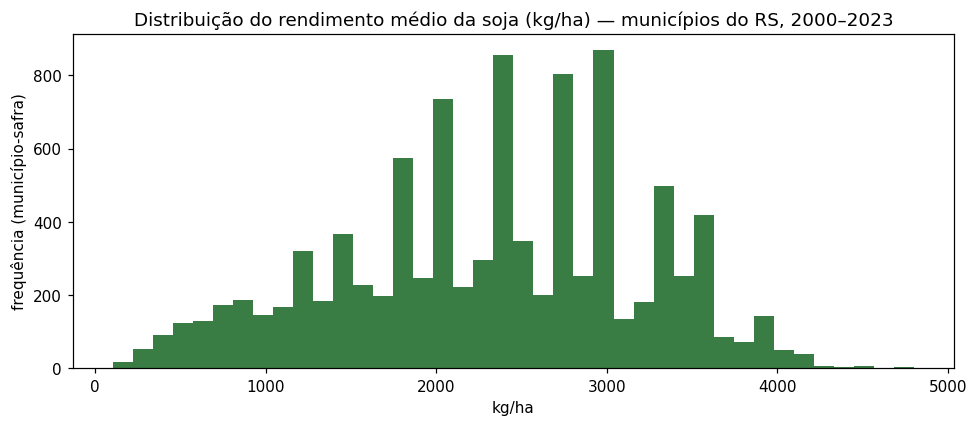

In [9]:
plt.figure(figsize=(9, 4))
plt.hist(painel["rendimento_kg_ha"].dropna(), bins=40, color="#3a7d44")
plt.title("Distribuição do rendimento médio da soja (kg/ha) — municípios do RS, 2000–2023")
plt.xlabel("kg/ha")
plt.ylabel("frequência (município-safra)")
plt.tight_layout()
plt.show()


### 8.3 Rendimento médio do RS × índice ONI, por safra

Média simples do rendimento entre os municípios com dado disponível em cada safra,
comparada ao ONI médio da janela de safra correspondente. Note a queda acentuada em
2005 — a safra 2004/2005 corresponde à grande seca histórica no RS, o que é uma boa
verificação de sanidade dos dados.

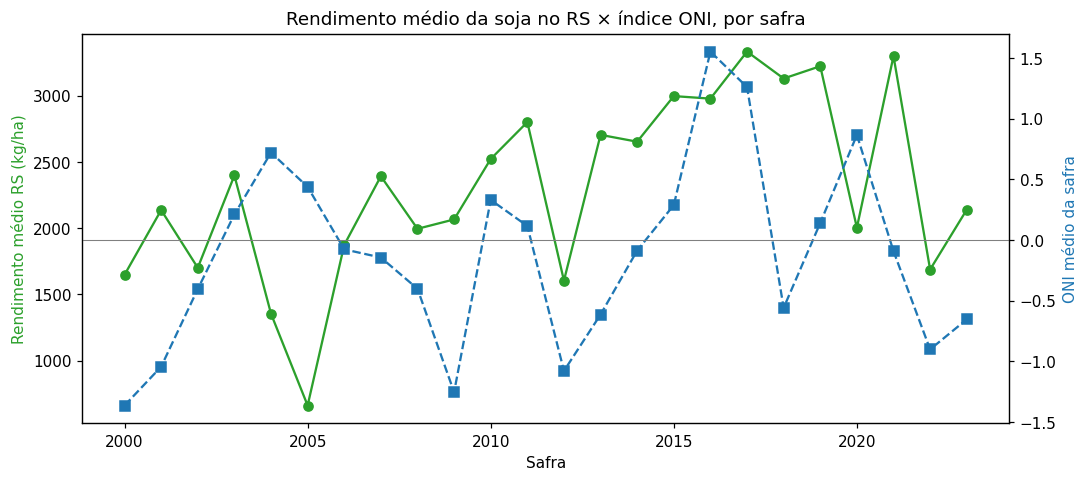

In [10]:
serie_rs = painel.groupby("ano_safra").agg(
    rendimento_medio_rs=("rendimento_kg_ha", "mean"),
    oni_media_safra=("oni_media_safra", "first"),
).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.plot(serie_rs["ano_safra"], serie_rs["rendimento_medio_rs"], color="tab:green", marker="o", label="Rendimento médio RS")
ax1.set_xlabel("Safra")
ax1.set_ylabel("Rendimento médio RS (kg/ha)", color="tab:green")
ax2 = ax1.twinx()
ax2.plot(serie_rs["ano_safra"], serie_rs["oni_media_safra"], color="tab:blue", marker="s", linestyle="--", label="ONI médio da safra")
ax2.axhline(0, color="grey", linewidth=0.7)
ax2.set_ylabel("ONI médio da safra", color="tab:blue")
plt.title("Rendimento médio da soja no RS × índice ONI, por safra")
plt.tight_layout()
plt.show()


### 8.4 Correlações entre rendimento, clima e ONI

Correlação de Pearson simples entre as variáveis numéricas do painel (nível
município-safra, sem controlar por município).

                             rendimento_kg_ha  area_plantada_ha  oni_media_safra  precipitacao_total_safra_mm  temperatura_media_safra_c
rendimento_kg_ha                         1.00              0.03             0.22                         0.32                      -0.29
area_plantada_ha                         0.03              1.00             0.03                         0.01                       0.04
oni_media_safra                          0.22              0.03             1.00                         0.35                       0.04
precipitacao_total_safra_mm              0.32              0.01             0.35                         1.00                      -0.06
temperatura_media_safra_c               -0.29              0.04             0.04                        -0.06                       1.00


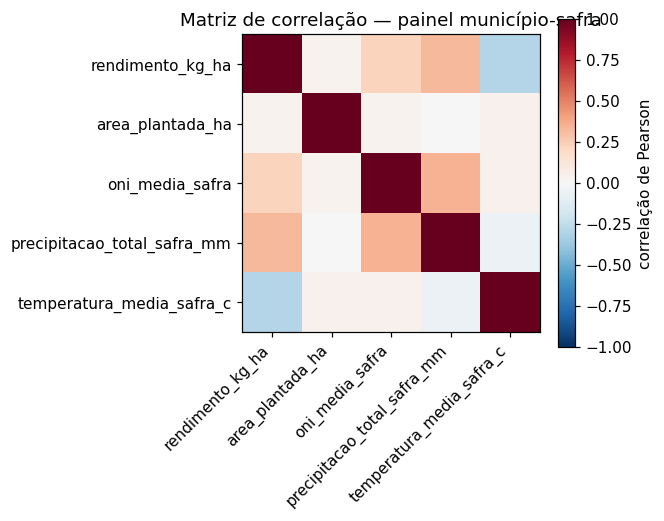

In [11]:
corr_cols = ["rendimento_kg_ha", "area_plantada_ha", "oni_media_safra",
             "precipitacao_total_safra_mm", "temperatura_media_safra_c"]
corr = painel[corr_cols].corr()
print(corr.round(2).to_string())

plt.figure(figsize=(6, 5))
im = plt.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
plt.colorbar(im, label="correlação de Pearson")
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Matriz de correlação — painel município-safra")
plt.tight_layout()
plt.show()


## 9. Conclusões preliminares e próximos passos

**Observações desta primeira análise exploratória:**

- A cobertura de municípios com produção de soja registrada cresce ao longo do
  período (de ~70% em 2000 para ~87% em 2023), refletindo a expansão da cultura
  no estado — isso deve ser considerado ao interpretar médias estaduais dos anos
  iniciais da série.
- A série de rendimento médio do RS captura corretamente eventos climáticos
  conhecidos, como a quebra de safra de 2004/2005 (grande seca histórica).
- No nível município-safra (sem separar por município), a correlação entre
  rendimento e ONI é fraca a moderada (~0,22) e entre rendimento e precipitação
  acumulada na safra é moderada (~0,32) — coerente com a literatura (ver seção
  2.2 do artigo), mas mostra que variáveis agregadas simples não bastam
  sozinhas; é esperado que Random Forest / Gradient Boosting capturem melhor as
  interações não lineares na etapa de modelagem.

**Limitações já identificadas nesta base:**

- A janela de safra do ONI (OND+NDJ do ano anterior, DJF+JFM do ano da safra) é
  uma primeira aproximação; deve ser revisada/testada contra alternativas.
- Municípios distantes de todas as 45 estações do INMET têm o clima estimado por
  uma estação potencialmente longe (ver distribuição de `dist_km` na seção 4) —
  isso é uma fonte de ruído a documentar no artigo.
- Estações em `Pane` geram lacunas nos dados diários de INMET, refletidas como
  `NaN` na agregação por safra.
- A adubação fosfatada (Embrapa/CQFS-RS/SC) ainda **não está integrada** ao
  painel — é uma tabela de referência por classe de solo, não uma série por
  município (ver `dataset/README.md`), e exige uma hipótese explícita de
  mapeamento região→classe de solo antes de poder virar uma coluna do painel.

**Próximos passos (N2):**

1. Definir e documentar a hipótese de classe de solo por região para incorporar
   a adubação fosfatada como atributo.
2. Implementar o split temporal (treino em safras antigas, teste nas mais
   recentes) e as duas linhas de base (média histórica expandida do município;
   rendimento da safra anterior).
3. Treinar e comparar Regressão Linear, Random Forest e Gradient Boosting
   (MAE, RMSE, R²).
4. Aplicar SHAP ao melhor modelo.
